In [11]:
import sys
sys.path.append('..')
from encoder import FMEncoder
import fm_ddsp
import torch

%load_ext autoreload
%autoreload 2

from fm_ddsp import fm_renderer, make_mod_matrix
from loss import multiscale_stft_loss
import torch
import numpy as np
import matplotlib.pyplot as plt

f0 = 440.0
ratios = torch.tensor([3.0, 1.0, 1.0, 1.0])
levels = torch.tensor([0.8, 1.0, 0.0, 0.0])

mod_matrix = make_mod_matrix(torch.tensor([0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]))
carrier_weights = torch.tensor([0.0, 1.0, 0.0, 0.0])
audio = fm_renderer(f0, ratios, levels, mod_matrix, carrier_weights, 16000, 1.0)
print("Audio shape:", audio.shape)
print("Import successful")





The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Audio shape: torch.Size([16000])
Import successful


In [12]:
encoder = FMEncoder()
x = torch.randn(4, 2049)

params = encoder(x)
for key, val in params.items():
    print(f"{key}: {val.shape}")

levels: torch.Size([4, 4])
mod_values: torch.Size([4, 7])
ratios: torch.Size([4, 4])
carrier_weights: torch.Size([4, 4])


mel spec shape: torch.Size([256, 16])


NameError: name 'ptl' is not defined

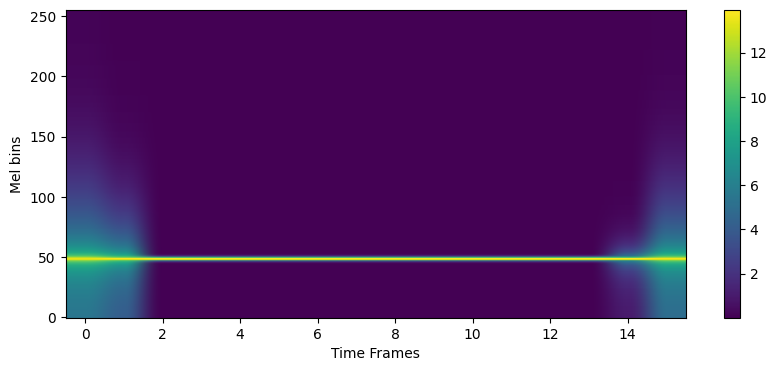

In [14]:
import torchaudio
Fs = 16000
n_fft = 4096
n_mels = 256

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate = Fs,
    n_fft=n_fft,
    n_mels=n_mels,
    hop_length=n_fft // 4
)

audio = fm_ddsp.sin_wav(440, Fs, 1.0)
mel_spec = mel_transform(audio)
print("mel spec shape:", mel_spec.shape)

plt.figure(figsize=(10, 4))
plt.imshow(torch.log1p(mel_spec).numpy(),
           aspect='auto',
           origin='lower')
plt.colorbar()
plt.xlabel('Time Frames')
plt.ylabel('Mel bins')
ptl.title('Mel Spectrogram')
plt.show()

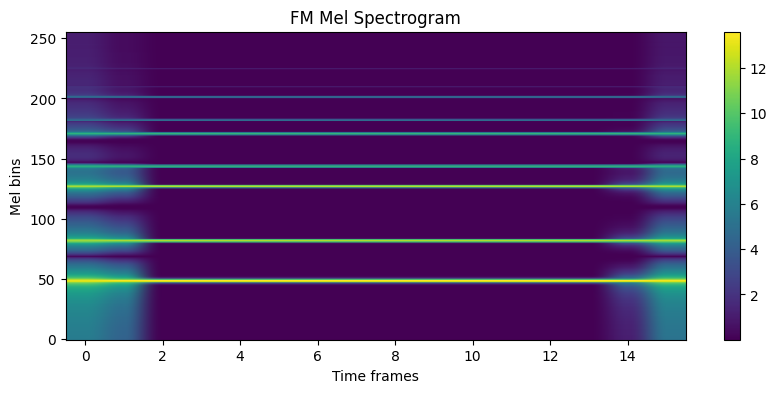

In [15]:
f0 = 440.0
ratios = torch.tensor([3.0, 1.0, 1.0, 1.0])
levels = torch.tensor([0.8, 1.0, 0.0, 0.0])
mod_matrix = make_mod_matrix(torch.tensor([0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]))
carrier_weights = torch.tensor([0.0, 1.0, 0.0, 0.0])
fm_audio = fm_renderer(f0, ratios, levels, mod_matrix, carrier_weights, 16000, 1.0)

mel_spec = mel_transform(fm_audio)
plt.figure(figsize=(10, 4))
plt.imshow(torch.log1p(mel_spec).numpy(),
           aspect='auto',
           origin='lower')
plt.colorbar()
plt.xlabel('Time frames')
plt.ylabel('Mel bins')
plt.title('FM Mel Spectrogram')
plt.show()